In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import cv2, random, os
from pathlib import Path
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import normalize
import math
import seaborn as sns
import numpy as np
import torchvision.transforms as T
from urllib.parse import unquote
import time
from tqdm import tqdm
from torchvision.transforms import functional as TF

In [3]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [5]:
train_df = pd.read_csv("/kaggle/input/datasets/kaggleju6se4pp/split-ready-data/train_split.csv")
val_df   = pd.read_csv("/kaggle/input/datasets/kaggleju6se4pp/split-ready-data/val_split.csv")
val_gt  = pd.read_csv("/kaggle/input/datasets/kaggleju6se4pp/split-ready-data/val_gt.csv")

In [6]:
TRAIN_DIR = Path("/kaggle/input/competitions/landmark-recognition-2021/train")
TEST_DIR  = Path("/kaggle/input/competitions/landmark-recognition-2021/test")

In [7]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
torch.backends.cudnn.benchmark = True

In [8]:
def make_subset(df, frac=0.05, seed=42):
    df = df.sample(frac=frac, random_state=seed).reset_index(drop=True)
    return df

def split_train_val_by_class(df, val_ratio=0.2, seed=42):
    train_parts = []
    val_parts = []

    rng = np.random.RandomState(seed)

    for cls, g in df.groupby("landmark_id"):
        g = g.sample(frac=1, random_state=seed).reset_index(drop=True)
        n = len(g)

        if n == 1:
            train_parts.append(g)
            continue

        n_val = max(1, int(round(n * val_ratio)))
        if n_val >= n:
            n_val = n - 1

        val_idx = rng.choice(n, size=n_val, replace=False)
        val_mask = np.zeros(n, dtype=bool)
        val_mask[val_idx] = True

        val_parts.append(g[val_mask])
        train_parts.append(g[~val_mask])

    train_df = pd.concat(train_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    val_df = pd.concat(val_parts).sample(frac=1, random_state=seed).reset_index(drop=True) if val_parts else pd.DataFrame(columns=df.columns)

    return train_df, val_df

In [ ]:
CFG = {
    'backbone': 'tf_efficientnet_b3',
    'embedding_size': 256,
    'batch_size': 64,
    'image_size': 256,
    'epochs': 5,
    'lr': 0.0001,
    'margin': 0.3,
    'scale': 20.0,
    'device': 'cuda'
}

In [10]:
class LandmarkDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def load_image(self, img_id):
        path = self.img_dir / img_id[0] / img_id[1] / img_id[2] / f"{img_id}.jpg"
        img = Image.open(path).convert("RGB")
        return ImageOps.exif_transpose(img)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self.load_image(row["id"])
        if self.transform:
            img = self.transform(img)
        label = int(row["label_idx"])
        return img, torch.tensor(label, dtype=torch.long)

In [ ]:
train_tfms = T.Compose([
    T.Resize((CFG["image_size"], CFG["image_size"])),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    T.RandomRotation(degrees=15),
    T.CenterCrop(CFG["image_size"]),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.RandomHorizontalFlip()
])

val_tfms = T.Compose([
    T.Resize((CFG["image_size"], CFG["image_size"])),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.RandomHorizontalFlip()
])

In [12]:
print(f"Исходный train: {len(train_df)}, val: {len(val_df)}")

train_clean = train_df[train_df['landmark_id'] != -1].copy()
val_clean   = val_df[val_df['landmark_id'] != -1].copy()

print(f"После удаления дистракторов train: {len(train_clean)}, val: {len(val_clean)}")


top500_classes = train_clean['landmark_id'].value_counts().head(500).index
train_top = train_clean[train_clean['landmark_id'].isin(top500_classes)].copy()
val_top   = val_clean[val_clean['landmark_id'].isin(top500_classes)].copy()

print(f"Топ-500: train {len(train_top)} изображений, val {len(val_top)} изображений")
print(f"Число классов: {len(top500_classes)}")



unique_labels = sorted(train_top['landmark_id'].unique())
label2idx = {l: i for i, l in enumerate(unique_labels)}
idx2label = {i: l for l, i in label2idx.items()}
num_classes = len(label2idx)
print(f"Уникальных классов в топ-500: {num_classes}")



train_top['label_idx'] = train_top['landmark_id'].map(label2idx)
val_top['label_idx']   = val_top['landmark_id'].map(label2idx)

Исходный train: 1057798, val: 317340
После удаления дистракторов train: 1057798, val: 264450
Топ-500: train 117239 изображений, val 29442 изображений
Число классов: 500
Уникальных классов в топ-500: 500


In [13]:
train_ds = LandmarkDataset(train_top, TRAIN_DIR, transform=train_tfms)
val_ds   = LandmarkDataset(val_top, TRAIN_DIR, transform=val_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [15]:
class GeM(nn.Module):
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * float(p))
        self.eps = eps

    def forward(self, x):
        return x.clamp(min=self.eps).pow(self.p).mean(dim=(-1, -2)).pow(1.0 / self.p)

In [16]:
class EmbeddingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            CFG["backbone"],
            pretrained=True,
            num_classes=0
        )
        self.pool = GeM(3.0)
        self.fc = nn.Linear(self.backbone.num_features, CFG["embedding_size"])
        self.bn = nn.BatchNorm1d(CFG["embedding_size"])
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = self.pool(x)
        x = self.fc(x)
        x = self.dropout(x)
        x = self.bn(x)
        return F.normalize(x, dim=1)

In [17]:
class ArcFaceLoss(nn.Module):
    def __init__(self, num_classes, embedding_size, margin=0.5, scale=64.0):
        super().__init__()
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_size))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        weight_norm = F.normalize(self.weight, dim=1)
        embeddings_norm = F.normalize(embeddings, dim=1)
        cosine = F.linear(embeddings_norm, weight_norm)

        labels = labels.long()
        assert labels.min() >= 0 and labels.max() < self.num_classes, "Метка вне допустимого диапазона"

        theta = torch.acos(torch.clamp(cosine, -1.0 + 1e-7, 1.0 - 1e-7))
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1)
        theta_with_margin = theta + one_hot * self.margin
        output = torch.cos(theta_with_margin) * self.scale
        return F.cross_entropy(output, labels)

In [ ]:
class PartialArcFaceLoss(nn.Module):
    def __init__(self, num_classes, embedding_size, margin=0.3, scale=30.0,
                 neg_class_num=2048):
        super().__init__()
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale
        self.neg_class_num = neg_class_num

        self.W = nn.Parameter(torch.FloatTensor(num_classes, embedding_size))
        nn.init.xavier_uniform_(self.W)

        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)
        self.mm = math.sin(math.pi - margin) * margin

    def forward(self, embeddings, labels):
        W_norm = F.normalize(self.W)

        pos_classes = torch.unique(labels)
        if self.neg_class_num > 0 and len(pos_classes) < self.neg_class_num:
            all_classes = torch.arange(self.num_classes, device=embeddings.device)
            mask = torch.ones(self.num_classes, dtype=torch.bool, device=embeddings.device)
            mask[pos_classes] = False
            neg_pool = all_classes[mask]
            if len(neg_pool) > 0:
                num_neg = min(self.neg_class_num - len(pos_classes), len(neg_pool))
                neg_classes = neg_pool[torch.randperm(len(neg_pool))[:num_neg]]
            else:
                neg_classes = torch.tensor([], dtype=torch.long, device=embeddings.device)
            sub_classes = torch.cat([pos_classes, neg_classes])
        else:
            sub_classes = torch.arange(self.num_classes, device=embeddings.device)

        sub_W = W_norm[sub_classes]

        sub_class_to_idx = {cls.item(): i for i, cls in enumerate(sub_classes)}
        mapped_labels = torch.tensor([sub_class_to_idx[l.item()] for l in labels],
                                     device=labels.device, dtype=torch.long)

        cosine = F.linear(embeddings, sub_W)

        sine = torch.sqrt((1.0 - cosine**2).clamp(0, 1))
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, mapped_labels.view(-1, 1), 1)

        logits = one_hot * phi + (1 - one_hot) * cosine
        logits *= self.scale

        loss = F.cross_entropy(logits, mapped_labels)
        return loss

In [19]:
def average_precision(gt_label, preds):
    for i, (pred_label, _) in enumerate(preds, 1):
        if pred_label == gt_label:
            return 1.0 / i
    return 0.0

In [20]:
def compute_gap(prediction_strings, gt_labels):
    ap_sum = 0.0

    for pred_str, gt in zip(prediction_strings, gt_labels):
        if not pred_str.strip():
            ap = 0.0
        else:
            parts = pred_str.strip().split()
            pred_list = []

            for p in range(0, len(parts), 2):
                lbl = int(parts[p])
                conf = float(parts[p+1])
                pred_list.append((lbl, conf))

            pred_list.sort(key=lambda x: x[1], reverse=True)
            ap = average_precision(gt, pred_list)

        ap_sum += ap

    return ap_sum / len(gt_labels)

In [21]:
def get_prediction_strings(logits, topk=5):
    probs = logits.softmax(dim=1)
    topk_vals, topk_idx = probs.topk(topk, dim=1)

    results = []

    for vals, idxs in zip(topk_vals, topk_idx):
        parts = []
        for v, i in zip(vals, idxs):
            parts.append(f"{int(i)} {float(v)}")
        results.append(" ".join(parts))

    return results

In [ ]:
@torch.no_grad()
def get_embeddings(model, loader):
    model.eval()

    all_embs = []
    all_labels = []

    for imgs, labels in loader:
        imgs = imgs.to(CFG["device"])

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            emb = model(imgs)

        all_embs.append(emb.cpu())
        all_labels.extend(labels.numpy())

    all_embs = torch.cat(all_embs, dim=0)  # [N, D]
    all_labels = torch.tensor(all_labels)

    return all_embs, all_labels

In [23]:
@torch.no_grad()
def evaluate_gap_knn(model, train_loader, val_loader, topk=5):
    model.eval()

    train_embs, train_labels = get_embeddings(model, train_loader)
    train_embs = F.normalize(train_embs, dim=1)
    train_labels_np = train_labels.cpu().numpy()

    all_preds = []
    all_gts = []

    for imgs, labels in val_loader:
        imgs = imgs.to(CFG["device"])
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            val_embs = model(imgs).cpu()
        val_embs = F.normalize(val_embs, dim=1)

        sim = val_embs @ train_embs.T

        topk_vals, topk_idx = sim.topk(topk, dim=1)

        for vals, idxs, gt in zip(topk_vals, topk_idx, labels):
            unique = {}
            for v, idx in zip(vals, idxs):
                lbl = int(train_labels_np[idx])
                conf = float(v)
                if lbl not in unique or conf > unique[lbl]:
                    unique[lbl] = conf

            sorted_items = sorted(unique.items(), key=lambda x: x[1], reverse=True)[:topk]
            parts = [f"{lbl} {conf}" for lbl, conf in sorted_items]
            all_preds.append(" ".join(parts))
            all_gts.append(gt.item())

    for i in range(min(5, len(all_preds))):
        print(f"\n--- Sample {i} (GT={all_gts[i]}) ---")
        parts = all_preds[i].split()
        for p in range(0, len(parts), 2):
            print(f"  Pred: {parts[p]} conf={float(parts[p+1]):.4f}")

    return compute_gap(all_preds, all_gts)

In [24]:
print(CFG)

{'backbone': 'tf_efficientnet_b3', 'embedding_size': 256, 'batch_size': 64, 'image_size': 256, 'epochs': 5, 'lr': 0.0001, 'margin': 0.3, 'scale': 20.0, 'device': 'cuda'}


In [ ]:
start = time.time()
imgs, labels = next(iter(train_loader))
print("Batch load time:", time.time() - start)

Batch load time: 7.225155591964722


In [ ]:
for imgs, labels in train_loader:
    break

start = time.time()
for i, (imgs, labels) in zip(range(10), train_loader):
    pass
total = time.time() - start
print(f"10 batches: {total:.2f} sec, average per batch: {total/10:.3f} sec")

10 batches: 12.37 sec, average per batch: 1.237 sec


In [27]:
import sys
from tqdm import tqdm

In [28]:
CFG["batch_size"] = 4
ACCUMULATION_STEPS = 4

In [ ]:
model = EmbeddingNet().to(CFG["device"])
criterion = PartialArcFaceLoss(
    num_classes=len(label2idx),
    embedding_size=CFG["embedding_size"],
    margin=CFG["margin"],
    scale=CFG["scale"],
    neg_class_num=1024
).to(CFG["device"])

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=CFG["lr"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG["epochs"]
)

scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

imgs, labels = next(iter(train_loader))
imgs = imgs.to(CFG["device"])
labels = labels.to(CFG["device"])

with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
    emb = model(imgs)
    loss = criterion(emb, labels)

if torch.isnan(loss):
    print("NaN detected!")
    raise ValueError("NaN in loss")

print("Sanity check OK:", emb.shape, loss.item())

best_val_gap = 0.0

for epoch in range(CFG["epochs"]):
    print(torch.cuda.memory_summary(device=CFG["device"], abbreviated=True))
    model.train()
    criterion.train()
    total_loss = 0.0
    total = 0
    optimizer.zero_grad()

    loop = tqdm(train_loader, desc=f'Epoch {epoch+1}', file=sys.stdout, mininterval=1.0)
    for batch_idx, (imgs, labels) in enumerate(loop):
        imgs = imgs.to(CFG["device"], non_blocking=True)
        labels = labels.to(CFG["device"], non_blocking=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            embeddings = model(imgs)
            loss = criterion(embeddings, labels)

        loss = loss / ACCUMULATION_STEPS
        scaler.scale(loss).backward()

        bs = labels.size(0)
        total_loss += loss.item() * bs * ACCUMULATION_STEPS
        total += bs

        if (batch_idx + 1) % ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        if (batch_idx + 1) % 10 == 0:
            loop.set_postfix(loss=loss.item() * ACCUMULATION_STEPS)
            sys.stdout.flush()
        del embeddings, loss
        torch.cuda.empty_cache()

    if (batch_idx + 1) % ACCUMULATION_STEPS != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    train_loss = total_loss / max(total, 1)

    val_gap = evaluate_gap_knn(model, train_loader, val_loader, topk=5)

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} val_gap={val_gap:.4f}")

    if val_gap > best_val_gap:
        best_val_gap = val_gap
        torch.save({
            "model": model.state_dict(),
            "criterion": criterion.state_dict(),
            "label2idx": label2idx,
            "idx2label": idx2label,
            "cfg": CFG,
        }, "/kaggle/working/best_arcface_debug.pth")
        print("Saved best checkpoint")

    scheduler.step()

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Sanity check OK: torch.Size([64, 256]) 13.202027320861816
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   7002 MiB |   7011 MiB |  13665 MiB |   6663 MiB |
|---------------------------------------------------------------------------|
| Active memory         |   7002 MiB |   7011 MiB |  13665 MiB |   6663 MiB |
|---------------------------------------------------------------------------|
| Requested memory      |   7002 MiB |   7011 MiB |  13665 MiB |   6663 MiB |
|-----

In [37]:
index_tfms = T.Compose([
    T.Resize((CFG["image_size"], CFG["image_size"])),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
train_index_ds = LandmarkDataset(train_top, TRAIN_DIR, transform=index_tfms)
train_index_loader = DataLoader(
    train_index_ds,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [31]:
pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 64.7 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:
device = CFG["device"]
@torch.no_grad()
def get_all_embeddings(loader, model):
    model.eval()
    all_embs, all_labels = [], []
    for imgs, labels in tqdm(loader, desc="Extracting train embeddings"):
        imgs = imgs.to(device)
        emb = model(imgs)
        all_embs.append(emb.cpu())
        all_labels.extend(labels.numpy())
    return torch.cat(all_embs, dim=0), np.array(all_labels)

train_embs, train_labels_idx = get_all_embeddings(train_index_loader, model)
train_embs = F.normalize(train_embs, dim=1).numpy().astype('float32')
print(f"Train embeddings shape: {train_embs.shape}")

Extracting train embeddings: 100%|██████████| 1832/1832 [08:22<00:00,  3.64it/s]  


Train embeddings shape: (117239, 256)


In [39]:
dim = train_embs.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(train_embs)
print(f"Index built with {index.ntotal} vectors")

Index built with 117239 vectors


In [40]:
class TestDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def load_image(self, img_id):
        path = self.img_dir / img_id[0] / img_id[1] / img_id[2] / f"{img_id}.jpg"
        img = Image.open(path).convert("RGB")
        return ImageOps.exif_transpose(img)

    def __getitem__(self, idx):
        img_id = self.df.loc[idx, "id"]
        img = self.load_image(img_id)
        if self.transform:
            img = self.transform(img)
        return img, img_id

test_tfms = T.Compose([
    T.Resize((CFG["image_size"], CFG["image_size"])),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_df = pd.read_csv("/kaggle/input/competitions/landmark-recognition-2021/sample_submission.csv")
test_ds = TestDataset(test_df, TEST_DIR, transform=test_tfms)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

In [ ]:
@torch.no_grad()
def predict_test_tta(model, test_loader, faiss_index, train_labels_idx, idx2label, topk=100, threshold=0.0):
    model.eval()
    test_ids = []
    pred_strings = []

    for imgs, img_ids in tqdm(test_loader, desc="Predicting test with TTA"):
        imgs = imgs.to(device)  # [B, C, H, W]

        imgs_tta = []
        imgs_tta.append(imgs)
        imgs_tta.append(torch.flip(imgs, dims=[3]))
        imgs_tta.append(TF.rotate(imgs, angle=15, fill=0))
        imgs_tta.append(TF.rotate(imgs, angle=-15, fill=0))

        # (B*4, C, H, W)
        imgs_stacked = torch.cat(imgs_tta, dim=0)

        emb_all = model(imgs_stacked)                # [B*4, D]
        emb_all = F.normalize(emb_all, dim=1)

        B = imgs.size(0)
        emb_avg = emb_all.view(4, B, -1).mean(dim=0) # [B, D]

        emb_np = emb_avg.cpu().numpy().astype('float32')
        D, I = faiss_index.search(emb_np, topk)

        for i in range(B):
            label_conf = {}
            for j in range(topk):
                lbl_idx = train_labels_idx[I[i, j]]
                lbl = idx2label[lbl_idx]
                conf = float(D[i, j])
                if lbl not in label_conf or conf > label_conf[lbl]:
                    label_conf[lbl] = conf
            sorted_items = sorted(label_conf.items(), key=lambda x: x[1], reverse=True)
            if sorted_items and sorted_items[0][1] >= threshold:
                pred_str = " ".join(f"{lbl} {conf:.6f}" for lbl, conf in sorted_items[:100])
            else:
                pred_str = ""
            pred_strings.append(pred_str)
            test_ids.append(img_ids[i])

    return test_ids, pred_strings
test_ids, pred_strings = predict_test_tta(model, test_loader, index, train_labels_idx, idx2label,
                                      topk=100, threshold=0.3)

Predicting test with TTA: 100%|██████████| 162/162 [03:17<00:00,  1.22s/it]


In [42]:
@torch.no_grad()
def predict_test(model, test_loader, faiss_index, train_labels_idx, idx2label, topk=100, threshold=0.0):
    model.eval()
    test_ids = []
    pred_strings = []

    for imgs, img_ids in tqdm(test_loader, desc="Predicting test"):
        imgs = imgs.to(device)
        emb1 = model(imgs)
        emb2 = model(torch.flip(imgs, dims=[3]))
        emb = (emb1 + emb2) / 2.0
        emb = F.normalize(emb, dim=1).cpu().numpy().astype('float32')

        D, I = faiss_index.search(emb, topk)

        for i in range(len(D)):
            label_conf = {}
            for j in range(topk):
                lbl_idx = train_labels_idx[I[i, j]]
                lbl = idx2label[lbl_idx]
                conf = float(D[i, j])
                if lbl not in label_conf or conf > label_conf[lbl]:
                    label_conf[lbl] = conf
            sorted_items = sorted(label_conf.items(), key=lambda x: x[1], reverse=True)
            if sorted_items and sorted_items[0][1] >= threshold:
                pred_str = " ".join(f"{lbl} {conf:.6f}" for lbl, conf in sorted_items[:100])
            else:
                pred_str = ""
            pred_strings.append(pred_str)
            test_ids.append(img_ids[i])

    return test_ids, pred_strings

test_ids, pred_strings = predict_test(model, test_loader, index, train_labels_idx, idx2label,
                                      topk=100, threshold=0.3)

Predicting test: 100%|██████████| 162/162 [01:29<00:00,  1.81it/s]


In [43]:
submission = pd.DataFrame({"id": test_ids, "landmarks": pred_strings})
sample_sub = pd.read_csv("/kaggle/input/competitions/landmark-recognition-2021/sample_submission.csv")
submission = sample_sub[["id"]].merge(submission, on="id", how="left")
submission["landmarks"] = submission["landmarks"].fillna("")
submission.to_csv("submission_minimal.csv", index=False)
print("Файл submission_minimal.csv сохранён!")

Файл submission_minimal.csv сохранён!


In [44]:
submission.head()

,id,landmarks
0,00084cdf8f600d00,21703 0.569303 31361 0.553360 102206 0.532206 ...
1,000b15b043eb8cf0,94310 0.419977 174181 0.414832 137203 0.409127...
2,0011a52f9b948fd2,113209 0.457309 83392 0.447513 31361 0.439747 ...
3,00141b8a5a729084,454 0.524154 23777 0.518206 149980 0.489103 73...
4,0018aa4b92532b77,55780 0.521569 91274 0.518593 27190 0.514322 9...


In [ ]:
info_path = "/kaggle/input/datasets/kaggleju6se4pp/categories/train_label_to_category.csv"

info_df = pd.read_csv(info_path)

id_to_name = dict(zip(info_df["landmark_id"], info_df["category"]))

print(f"Загружено {len(id_to_name)} категорий")

Загружено 203094 категорий


In [ ]:
info_path = "/kaggle/input/datasets/kaggleju6se4pp/categories/train_label_to_category.csv"
info_df = pd.read_csv(info_path)

def clean_category_name(category_url: str) -> str:
    name_part = category_url.rsplit('Category:', 1)[-1]
    name_part = name_part.rstrip('/')
    name_part = unquote(name_part)
    name_part = name_part.replace('_', ' ')
    return name_part

id_to_name = {}
for _, row in info_df.iterrows():
    lid = row['landmark_id']
    raw = row['category']
    id_to_name[lid] = clean_category_name(raw)

print(f"Загружено {len(id_to_name)} читаемых названий")

Загружено 203094 читаемых названий


In [50]:
for idx in range(5):
    img_id = test_ids[idx]
    preds = pred_strings[idx]

    print(f"\n===== Изображение {img_id} =====")
    if not preds.strip():
        print("  Нет предсказаний")
        continue

    parts = preds.strip().split()
    for p in range(0, len(parts), 2):
        landmark_id_str = parts[p]
        conf_str = parts[p+1]
        landmark_id = int(landmark_id_str)
        name = id_to_name.get(landmark_id, f"Неизвестный ID {landmark_id}")
        print(f"  {name:<40s}  уверенность: {float(conf_str):.4f}")


===== Изображение 00084cdf8f600d00 =====
  Zvartnots                                 уверенность: 0.5693
  Mount Wutai                               уверенность: 0.5534
  Lake Lucerne                              уверенность: 0.5322
  Market Square, Lviv                       уверенность: 0.5293
  Stonehenge                                уверенность: 0.5019
  Kissimmee Air Museum                      уверенность: 0.4905
  Media contributed by the ETH-Bibliothek   уверенность: 0.4885
  Trevi fountain                            уверенность: 0.4867
  Saiful Muluk Lake                         уверенность: 0.4864
  Salève                                    уверенность: 0.4824
  Olympiastadion Berlin                     уверенность: 0.4766
  Tatev                                     уверенность: 0.4747
  Begnas Lake                               уверенность: 0.4730
  Ternopil Pond                             уверенность: 0.4702
  Palace of Culture and Science             уверенность: 0.468

In [ ]:
@torch.no_grad()
def get_embeddings(model, loader, max_batches=None):
    model.eval()

    all_embs = []
    all_labels = []

    for batch_idx, (imgs, labels) in enumerate(loader):

        print(f"batch {batch_idx+1}")

        imgs = imgs.to(CFG["device"])

        with torch.amp.autocast(
            "cuda",
            enabled=torch.cuda.is_available()
        ):
            emb = model(imgs)

        all_embs.append(emb.cpu())
        all_labels.extend(labels.numpy())


        if max_batches is not None:
            if batch_idx + 1 >= max_batches:
                print(f"STOP at batch {max_batches}")
                break

    all_embs = torch.cat(all_embs, dim=0)
    all_labels = torch.tensor(all_labels)

    return all_embs, all_labels


[1/6] Extract TRAIN embeddings...
batch 1
batch 2
batch 3
batch 4
batch 5
batch 6
batch 7
batch 8
batch 9
batch 10
batch 11
batch 12
batch 13
batch 14
batch 15
batch 16
batch 17
batch 18
batch 19
batch 20
STOP at batch 20
train_embs shape: torch.Size([1280, 256])
done in 16.40 sec

[2/6] Extract VAL embeddings...
batch 1
batch 2
batch 3
batch 4
batch 5
batch 6
batch 7
batch 8
batch 9
batch 10
STOP at batch 10
val_embs shape: torch.Size([640, 256])
done in 10.84 sec

[3/6] Compute similarity matrix...
matrix size = 640 x 1280
sim_matrix shape: torch.Size([640, 1280])
done in 0.01 sec

[4/6] Find nearest neighbors...
done in 0.00 sec

[5/6] Sample predictions:
[0] GT=102 PRED=102 landmark=40530 conf=0.4318
[1] GT=261 PRED=261 landmark=107164 conf=0.4691
[2] GT=215 PRED=91 landmark=36748 conf=0.2964
[3] GT=22 PRED=22 landmark=8351 conf=0.7322
[4] GT=107 PRED=253 landmark=103899 conf=0.6051
[5] GT=124 PRED=124 landmark=50798 conf=0.8357
[6] GT=0 PRED=121 landmark=48753 conf=0.4600
[7] GT=

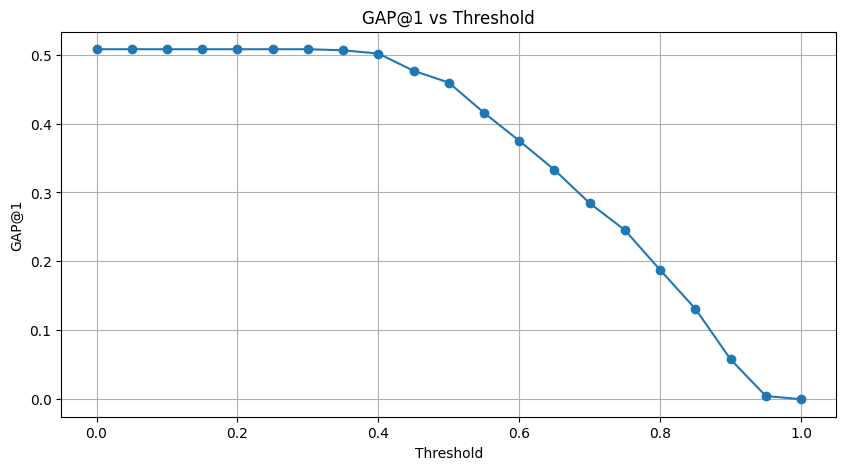

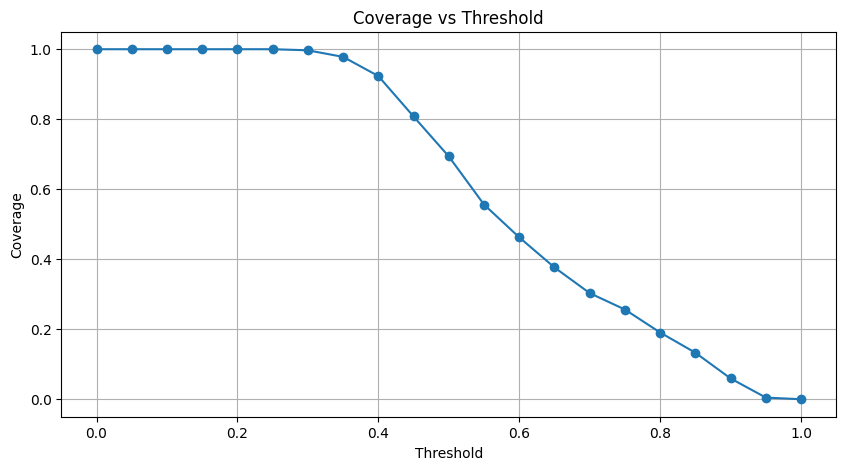

In [ ]:
@torch.no_grad()
def fast_threshold_analysis(
    model,
    train_loader,
    val_loader,
    idx2label,
    thresholds=np.arange(0.0, 1.01, 0.05)
):

    model.eval()



    print("\n[1/6] Extract TRAIN embeddings...")
    start = time.time()

    train_embs, train_labels = get_embeddings(
        model,
        train_loader,
        max_batches=20
    )


    print(f"train_embs shape: {train_embs.shape}")

    train_embs = F.normalize(train_embs, dim=1)

    train_labels = train_labels.numpy()

    print(f"done in {time.time() - start:.2f} sec")

    print("\n[2/6] Extract VAL embeddings...")
    start = time.time()

    val_embs, val_labels = get_embeddings(
        model,
        val_loader,
        max_batches=10
    )

    print(f"val_embs shape: {val_embs.shape}")

    val_embs = F.normalize(val_embs, dim=1)

    val_labels = val_labels.numpy()

    print(f"done in {time.time() - start:.2f} sec")


    print("\n[3/6] Compute similarity matrix...")
    start = time.time()

    print(
        f"matrix size = "
        f"{val_embs.shape[0]} x {train_embs.shape[0]}"
    )

    sim_matrix = val_embs @ train_embs.T

    print(f"sim_matrix shape: {sim_matrix.shape}")

    print(f"done in {time.time() - start:.2f} sec")


    print("\n[4/6] Find nearest neighbors...")
    start = time.time()

    best_scores, best_idxs = sim_matrix.max(dim=1)

    best_scores = best_scores.numpy()
    best_idxs = best_idxs.numpy()

    pred_labels = train_labels[best_idxs]

    print(f"done in {time.time() - start:.2f} sec")


    print("\n[5/6] Sample predictions:")

    for i in range(min(10, len(pred_labels))):

        gt = val_labels[i]
        pred = pred_labels[i]

        landmark_id = idx2label[pred]

        conf = best_scores[i]

        print(
            f"[{i}] "
            f"GT={gt} "
            f"PRED={pred} "
            f"landmark={landmark_id} "
            f"conf={conf:.4f}"
        )


    print("\n[6/6] Threshold sweep...")

    metrics = []

    for threshold in thresholds:

        accepted = best_scores >= threshold

        coverage = accepted.mean()

        correct = (
            (pred_labels == val_labels)
            & accepted
        ).sum()

        gap1 = correct / len(val_labels)

        rejected = (~accepted).sum()

        print(
            f"thr={threshold:.2f} | "
            f"GAP@1={gap1:.4f} | "
            f"coverage={coverage:.4f} | "
            f"rejected={rejected}"
        )

        metrics.append({
            "threshold": threshold,
            "gap1": gap1,
            "coverage": coverage,
            "rejected": rejected
        })

    metrics_df = pd.DataFrame(metrics)

    predictions_df = pd.DataFrame({
        "gt_label_idx": val_labels,
        "pred_label_idx": pred_labels,
        "pred_landmark_id": [
            idx2label[x]
            for x in pred_labels
        ],
        "confidence": best_scores
    })

    print("\nAnalysis complete.")

    return metrics_df, predictions_df

metrics_df, predictions_df = fast_threshold_analysis(
    model,
    train_loader,
    val_loader,
    idx2label
)


print("\nMetrics table:")
print(metrics_df)



predictions_df.to_csv(
    "val_predictions.csv",
    index=False
)

print("\nSaved val_predictions.csv")



plt.figure(figsize=(10, 5))

plt.plot(
    metrics_df["threshold"],
    metrics_df["gap1"],
    marker="o"
)

plt.xlabel("Threshold")
plt.ylabel("GAP@1")
plt.title("GAP@1 vs Threshold")

plt.grid(True)

plt.show()



plt.figure(figsize=(10, 5))

plt.plot(
    metrics_df["threshold"],
    metrics_df["coverage"],
    marker="o"
)

plt.xlabel("Threshold")
plt.ylabel("Coverage")
plt.title("Coverage vs Threshold")

plt.grid(True)

plt.show()